# BigQuery test — average latest spread by BICS sector

Small exercise: connect to BigQuery from VS Code, query `Agg_Spread_Long` joined with `Agg_Fixed_Field`, and plot one chart.

Before running, complete the auth steps in `README.md` and fill in `PROJECT_ID` / `DATASET` below.

In [1]:
from google.cloud import bigquery
import pandas as pd
import matplotlib.pyplot as plt

PROJECT_ID = "insurance-backed-securities"   # <-- fill in
DATASET    = "Securities"      # <-- fill in

client = bigquery.Client(project=PROJECT_ID)
print(f"Connected to project: {client.project}")

/opt/anaconda3/lib/python3.12/site-packages/google/auth/_default.py:113: UserWarning: Your application has authenticated using end user credentials from Google Cloud SDK without a quota project. You might receive a "quota exceeded" or "API not enabled" error. See the following page for troubleshooting: https://cloud.google.com/docs/authentication/adc-troubleshooting/user-creds. 
  warnings.warn(_CLOUD_SDK_CREDENTIALS_WARNING)


Connected to project: insurance-backed-securities


## Smoke test — list tables in the dataset

In [2]:
tables = list(client.list_tables(f"{PROJECT_ID}.{DATASET}"))
for t in tables:
    print(t.table_id)

Agg_Fixed_Field
Agg_Spread_Long


## Query — latest spread per CUSIP, joined with sector metadata

In [3]:
sql = f"""
WITH latest AS (
  SELECT CUSIP, Spread,
         ROW_NUMBER() OVER (PARTITION BY CUSIP ORDER BY Date DESC) AS rn
  FROM `{PROJECT_ID}.{DATASET}.Agg_Spread_Long`
)
SELECT f.BICS_LEVEL_1_SECTOR_NAME AS sector,
       AVG(l.Spread) AS avg_spread,
       COUNT(*)      AS n_bonds
FROM latest l
JOIN `{PROJECT_ID}.{DATASET}.Agg_Fixed_Field` f USING (CUSIP)
WHERE l.rn = 1 AND f.BICS_LEVEL_1_SECTOR_NAME IS NOT NULL
GROUP BY sector
ORDER BY avg_spread DESC
"""

df = client.query(sql).to_dataframe()
df

/opt/anaconda3/lib/python3.12/site-packages/google/cloud/bigquery/table.py:2086: UserWarning: BigQuery Storage module not found, fetch data with the REST endpoint instead.
  warnings.warn(


,sector,avg_spread,n_bonds
0,Materials,64.614982,7
1,Communications,58.483707,9
2,Utilities,55.081461,15
3,Technology,53.278936,4
4,Energy,48.236019,16
5,Financials,47.075103,173
6,Consumer Discretionary,45.240277,28
7,Health Care,33.581024,4
8,Industrials,33.540777,32
9,Government,24.784717,8


## Bar chart — average latest spread by sector

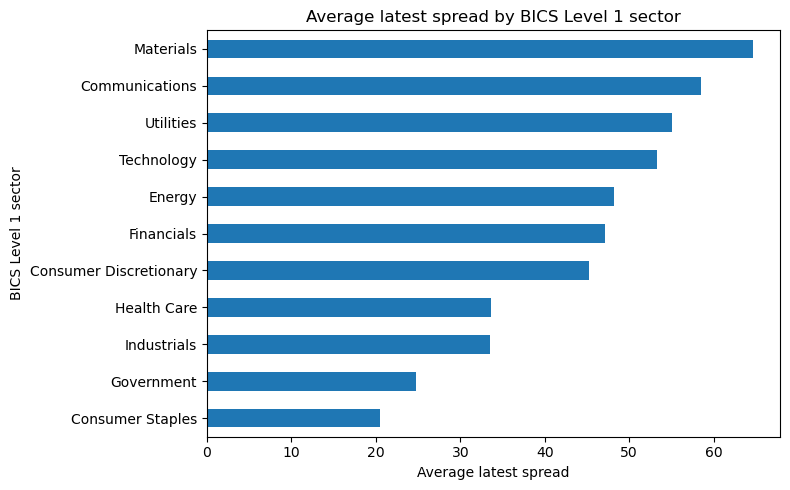

In [4]:
ax = df.plot.barh(x="sector", y="avg_spread", figsize=(8, 5), legend=False)
ax.invert_yaxis()
ax.set_xlabel("Average latest spread")
ax.set_ylabel("BICS Level 1 sector")
ax.set_title("Average latest spread by BICS Level 1 sector")
plt.tight_layout()
plt.show()